선형 커널 SVM 결과
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45

정확도: 0.8

비선형 커널 SVM (RBF) 결과
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.70      0.54      0.61        13
           2       0.62      0.77      0.69        13

    accuracy                           0.80        45
   macro avg       0.78      0.77      0.77        45
weighted avg       0.81      0.80      0.80        45

정확도: 0.8


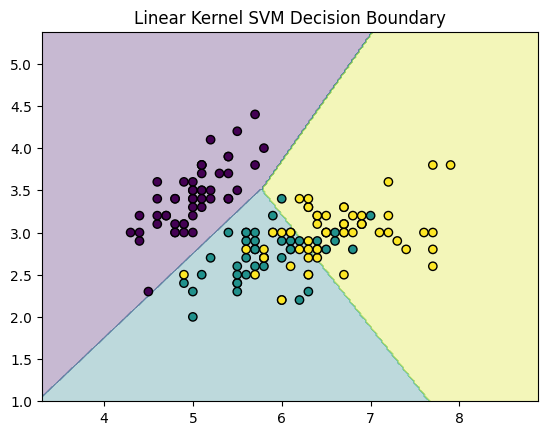

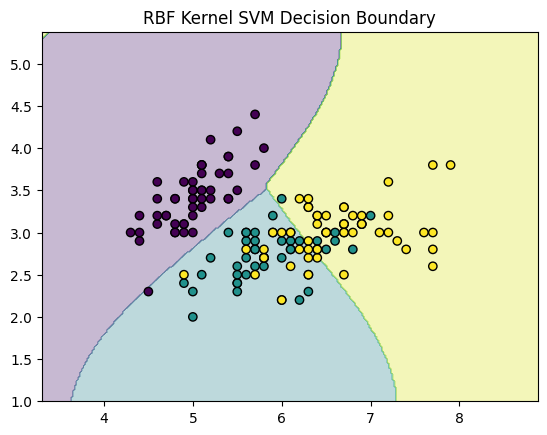

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 데이터 로드
iris = datasets.load_iris()
X = iris.data[:, :2]  # 두 개의 특성만 사용하여 시각화 가능하도록
y = iris.target

# 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 선형 커널 SVM
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

print("선형 커널 SVM 결과")
print(classification_report(y_test, y_pred_linear))
print("정확도:", accuracy_score(y_test, y_pred_linear))

# 비선형 커널 SVM (RBF)
rbf_svm = SVC(kernel='rbf', gamma=0.5)
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)

print("\n비선형 커널 SVM (RBF) 결과")
print(classification_report(y_test, y_pred_rbf))
print("정확도:", accuracy_score(y_test, y_pred_rbf))

# 시각화 함수 정의
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.show()

# 선형 커널과 비선형 커널 시각화
plot_decision_boundary(linear_svm, X, y, "Linear Kernel SVM Decision Boundary")
plot_decision_boundary(rbf_svm, X, y, "RBF Kernel SVM Decision Boundary")

- **선형 커널 (Linear Kernel)**
    - 데이터가 선형적으로 구분 가능할 때 사용하는 커널 
    - 선형 커널은 주어진 특성을 그대로 사용하여 초평면을 찾았다.
    - 단순한 내적을 통해서 정의했다.
    
- **비선형 커널 (Non-Linear Kernel)**
    - 데이터가 선형적으로 구분되지 않는 경우에 유용
    - **커널함수 사용해서 데이터를 고차원 공간으로 변환하여 선형적으로 구분한 가능한 형(커널트릭)태로 만든다.**
    - 커널 함수도  다양하게 존재
        - 다항커널, RBF, 시그모이드 등등
        - 다항커널로 좀 더 깊게 살펴볼 것

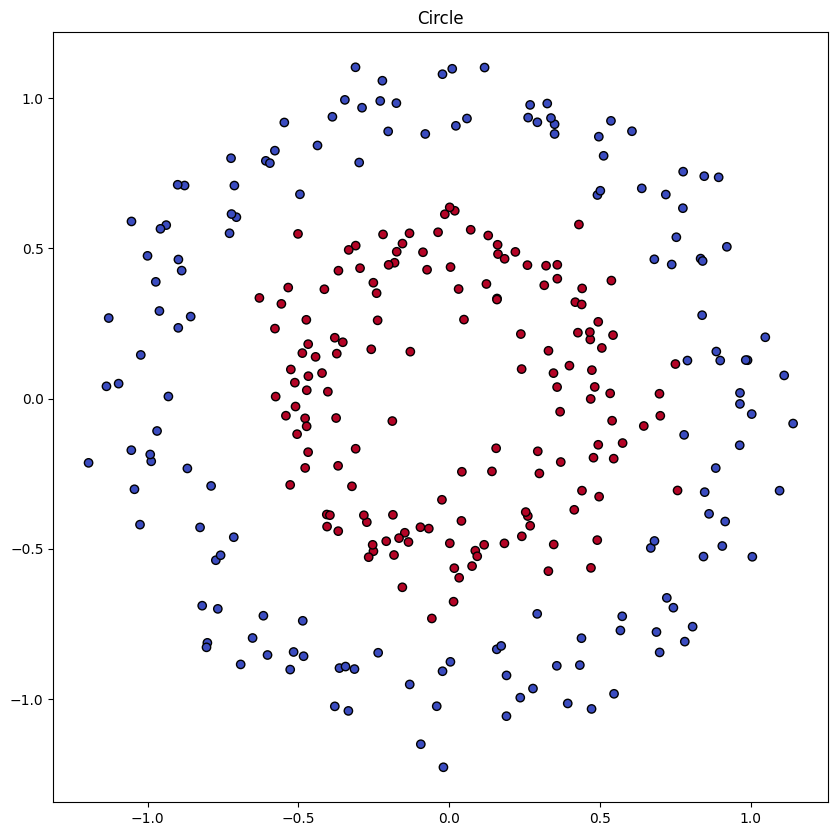

선형 커널 SVM 결과
              precision    recall  f1-score   support

           0       0.42      1.00      0.59        38
           1       0.00      0.00      0.00        52

    accuracy                           0.42        90
   macro avg       0.21      0.50      0.30        90
weighted avg       0.18      0.42      0.25        90

정확도: 0.4222222222222222

비선형 커널 SVM (RBF) 결과
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        52

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

정확도: 1.0


D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


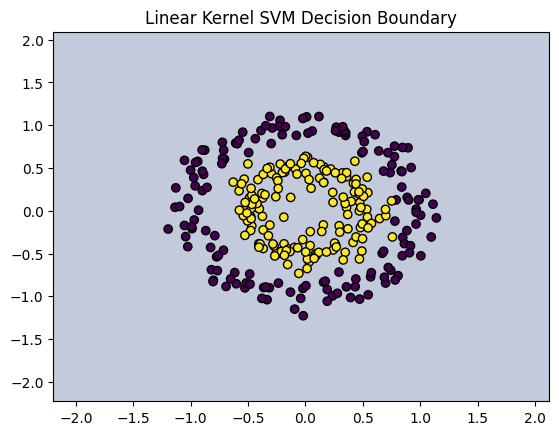

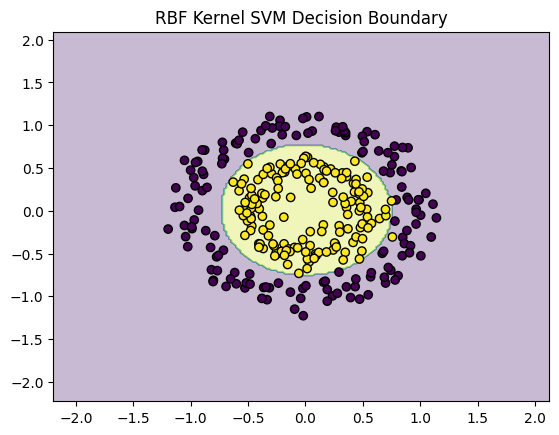

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. 선형으로 분류하기 어려운 데이터셋 생성
X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)
# 시각화
plt.figure(figsize=(10,10))
plt.scatter(X[:,0],X[:,1], c =y, cmap='coolwarm', edgecolor='k')
plt.title('Circle')
plt.show()


# 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 선형 커널 SVM
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

print("선형 커널 SVM 결과")
print(classification_report(y_test, y_pred_linear))
print("정확도:", accuracy_score(y_test, y_pred_linear))

# 비선형 커널 SVM (RBF)
rbf_svm = SVC(kernel='rbf', gamma=0.5)
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)

print("\n비선형 커널 SVM (RBF) 결과")
print(classification_report(y_test, y_pred_rbf))
print("정확도:", accuracy_score(y_test, y_pred_rbf))

# 시각화 함수 정의
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.show()

# 선형 커널과 비선형 커널 시각화
plot_decision_boundary(linear_svm, X, y, "Linear Kernel SVM Decision Boundary")
plot_decision_boundary(rbf_svm, X, y, "RBF Kernel SVM Decision Boundary")

### 비선형의 문제일 때 다항커널로 적용한다는 의미가 무엇일까?
- 고차원의 공간으로 매핑하여 새로운 공간의 선형적인 분리를 할 수 있도록 만드는 것을 의미 
- 다항 커널은 각 데이터 포인트 벡터 간의 내적을 거듭제곱하여서 변환해서 만들어 진다.
    - 결정경계가 단순한 선형 직선이 아닌 곡선의 형태로 나타나게 된다.


**다항 커널 (Polynomial Kernel)**
$$\( K(\mathbf{x}, \mathbf{y}) = (\mathbf{x} \cdot \mathbf{y} + c)^d \)$$

- 고차원 매핑 자체의 식을 사용해서 보게 되면
- x12y12 + 2(x1x2y1y2) + x22y22 + 2cx1y1 + 2cx2y2 + c2
- 새로운 고차원의 특성들로 변환이 된다.
    - 2차원인 (고차원) 공간에서 선형적으로 구분할 수 있도록 만들어주는 변환
    
- 원형 분포의 데이터는 2차원에서는 선형적으로 구분되지 않지만, 2차 다항 커널로 매핑된 고차원 공간에서는 초평면(선형 결정 경계)을 통해 분리 가능하다.

---
- **d 다항 차수**
    - 차수가 높아지면 더 복잡한 형태의 결정 경계를 만들 수 있다.
    - d=2 진행했을 경우에는 원형에 대한 것이 결정 경계가 가능한데, d =3 또는 n 더 높아지면 원형 외 더 복잡한 곡선의 형태의 경계가 형성될 수 있다.
    - d가 너무 크면 데이터에 과적합될 위험이 너무 크고, 데이터의 구조에 맞게끔 적절한 차수를 조정하는 것이 좋다.
--- 
- **C 상수항**
    - 상수항 c : 두 벡터의 내적값에 상수 값이 더 해지는 경우, 다항 커널의 복잡성을 조절한다. 
    - 결정 경계 조정하는 경우 : c의 값에 따라 다항 커널이 생성하는 결정경계의 형태가 조금 변한다. c값이 커지면 모델이 더 복잡한 경계를 할 가능성이 높다.
    - 특성 간의 영향 조정: 커널 모델이 생성하는 경계가 더 곡선으로 형태로 변하거나 덜 변하게끔 도와주는 형태 
    
    

### 내적에 의미가 무엇일까?
- **두 벡터사이의 내적 X,y 내적의 값 계산**
- 내적의 결과 -> 두 벡터가 얼마나 비슷한 방향을 가졌는지, 값이 클수록 벡터가 서로 유사한 방향으로 갖는다는 것을 의미 

- **SVM에서 내적을 사용하는 이유?**
    - 고차원 매핑을 위한 기초
    - SVM 에서는 데이터를 고차원으로 매핑해서 선형적으로 구분할 수 있게 한다. 목표다.
    - 다항 커널은 거듭제곱 형태로 변환을 해서, 고차원 공간에서 두 데이터의 포인트간의 유사도를 측정할 수 있게 했다. 
    - 두 벡터가 얼마나 유사한지 측정하는 동시에, 거듭제곱하여서 이 둘의 고차원 매핑 효과를 만든다.
    
- **내적을 다항 커널로 변환하는 이유**
    - 다항 커널은 내적을 거듭제곱하여 두 벡터 간의 고차원 특성을 생성
    - 원래 차원에서는 비선형적인 데이터의 간의 관계를 고차원에서 선형적으로 구분할 수 있게 만든다.
    - 유사도 계산을 하는 것은 SVM이 데이터 포인트 간의 유사도를 통해 결정 경계를 형성할 때, 내적은 이 유사도를 표현하는 기본 단위가 된다. 
    - 고차원 공간에서 유사도가 높을수록 같은 클래스로 분류될 가능성이 높아지는 것, 유사도가 낮으면 다른 클래스로 분류될 가능성이 커진다.

- 만약 두 벡터가 거의 평행하고 유사하다. 내적값은 -> 큰 값을 가질 것
- 만약 두 벡터가 서로 다른 방향을 가지면 -> 내적값은 작아진다.
- 내적 값이 높고 낮음이 결국 각 데이터 포인트가 다른 포인트와 얼마나 유사한지 표현, 그 유사도 바탕 결정경계 형성


### 전체적인 SVM의 전체 적용과정을 살펴보자!
- **SVM의 목적** : 두 데이터의 클래스를 최대한 간격이 넓은 초평면으로 분류하는 방법, 이 초평면이 각 클래스에서 가장 가까운 데이터(서포트 벡터)와 거리 최대화하여 형성
    - 초평면의 정의 wx+b=0 형태로 정의
    - w 초평면의 방향인 가중치 벡터, b 절편
    - 두 클래스 간의 마진(간격)을 최대화 하기 위해 w, b를 찾는 것이 SVM의 목표 
- **최적화 문제** :
    - SVM의 최적화 목표는 ? : 서포트 벡터와 결정경계의 마진을 최대화 하는 것 제약조건이 포함된 최적화문제로 수립
    - 라그랑주 승수법을 사용하여 최적화 문제를 풀고, 서포트 벡터를 기반으로 결정경계를 계산한다.
    
-----
- **비선형 SVM과 커널 트릭인 경우**
- **선형적으로 데이터가 이뤄지지 않는 경우 커널 트릭을 사용하여 데이터를 고차원으로 매핑하고 그 공간에서 선형적으로 분류가 가능하도록 만든다.**
    - 데이터가 선형적으로 구분이 안 되는 원형, 곡선 형태 단일 선형 초평면으로는 어렵다.
    - 고차원으로 변형하면서 실제 데이터를 더 잘 선형으로 분리할 수 있다!
    
- **커널 트릭을 통한 고차원 매핑**
    - 두 데이터 포인트 간의 유사도를 고차원 공간으로 계산하여 데이터 매핑 없이 고차원의 내적 결과를 얻을 수 있다. ( 다항 커널을 사용 )

- **SVM의 최적화 방식이 비선형 커널에서의 변화를 보는 것**
    - 비선형이더라도 결국은 SVM의 최적화 방식은 본질적으로 동일하다. 차이는 결국 고차원 매핑을 고려하여 유사도 계산해서 커널 함수로 대체하여 최적화 하는 것일 뿐 나머지는 동일하다.
    


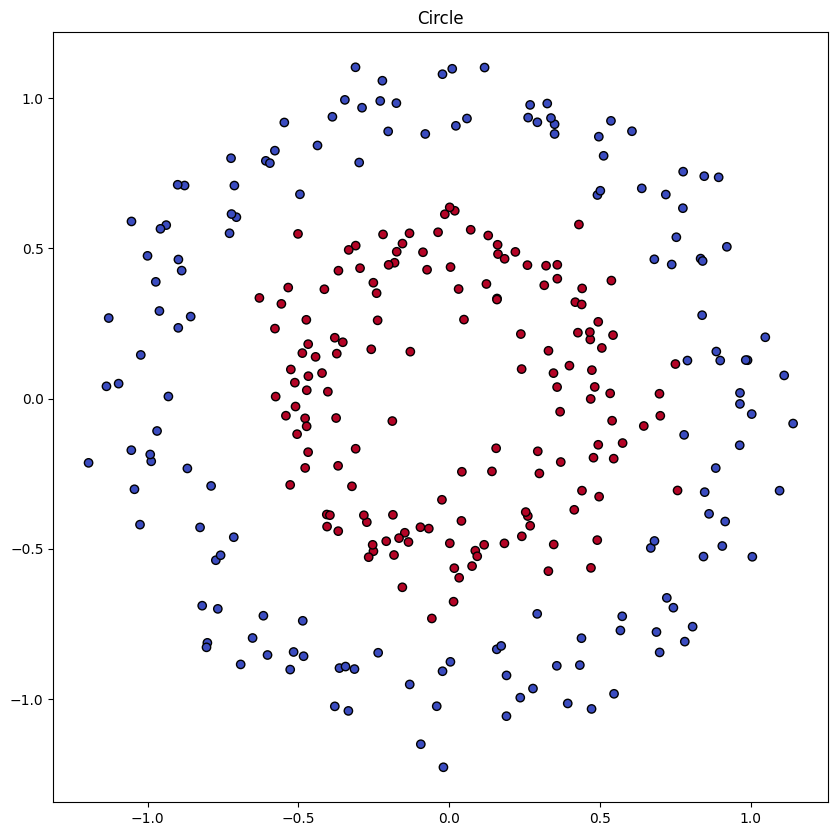

선형 커널 SVM 결과
              precision    recall  f1-score   support

           0       0.42      1.00      0.59        38
           1       0.00      0.00      0.00        52

    accuracy                           0.42        90
   macro avg       0.21      0.50      0.30        90
weighted avg       0.18      0.42      0.25        90

정확도: 0.4222222222222222

비선형 커널 SVM (RBF) 결과
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        52

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

정확도: 1.0


D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


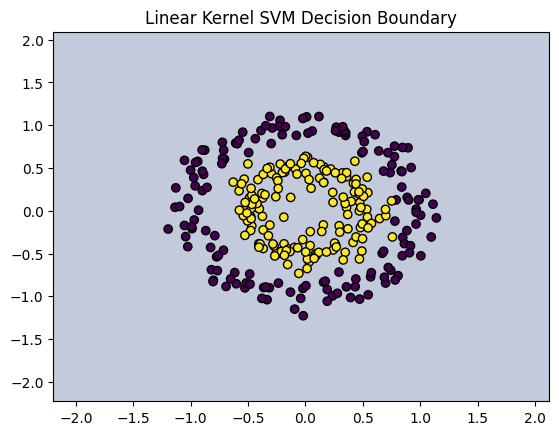

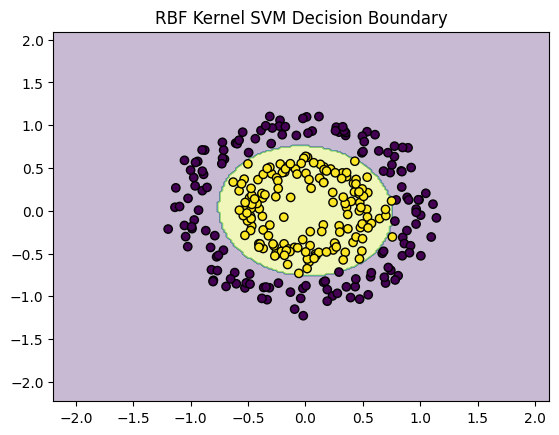

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. 선형으로 분류하기 어려운 데이터셋 생성
X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)
#X, y = make_circles(n_samples=300, noise=0.5, random_state=42)

plt.figure(figsize=(10,10))
plt.scatter(X[:,0],X[:,1], c =y, cmap='coolwarm', edgecolor='k')
plt.title('Circle')
plt.show()


# 학습 및 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 선형 커널 SVM
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

print("선형 커널 SVM 결과")
print(classification_report(y_test, y_pred_linear))
print("정확도:", accuracy_score(y_test, y_pred_linear))

# 비선형 커널 SVM (다항커널로)
rbf_svm = SVC(kernel='poly',degree=2, C=1.0)
rbf_svm.fit(X_train, y_train)
y_pred_rbf = rbf_svm.predict(X_test)

print("\n비선형 커널 SVM (RBF) 결과")
print(classification_report(y_test, y_pred_rbf))
print("정확도:", accuracy_score(y_test, y_pred_rbf))

# 시각화 함수 정의
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.show()

# 선형 커널과 비선형 커널 시각화
plot_decision_boundary(linear_svm, X, y, "Linear Kernel SVM Decision Boundary")
plot_decision_boundary(rbf_svm, X, y, "RBF Kernel SVM Decision Boundary")

RBF 커널 (Radial Basis Function Kernel, Gaussian Kernel)
$$\( K(\mathbf{x}, \mathbf{y}) = \exp(-\gamma \|\mathbf{x} - \mathbf{y}\|^2) \)$
$$


Sigmoid 커널
$$\( K(\mathbf{x}, \mathbf{y}) = \tanh(\alpha (\mathbf{x} \cdot \mathbf{y}) + c) \)$$

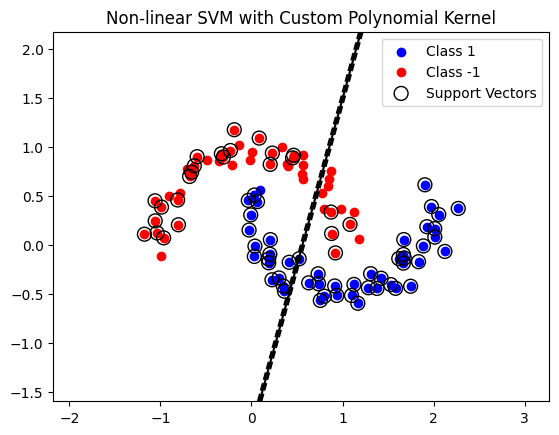

In [3]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 다항 커널 함수 정의
def polynomial_kernel(x1, x2, c=1, degree=1):
    """
    두 벡터 x1, x2의 다항 커널 값을 계산합니다.
    매개변수:
        - x1, x2: 두 데이터 포인트 벡터
        - c: 상수 항 (기본값 1)
        - degree: 다항식 차수 (기본값 2)
    반환값:
        - 다항 커널 계산 결과
    """
    return (np.dot(x1, x2) + c) ** degree   # 다항함수 반환

# 비선형 SVM 학습 함수 (다항 커널 기반)
def fit_nonlinear_svm(X, y, C=1.0, kernel=polynomial_kernel):
    """
    SVM 듀얼 문제 최적화하여 라그랑주 승수(alpha)와 결정 경계의 절편(b)을 찾는 함수
    매개변수:
        - X: 입력 데이터 (n_samples, n_features)
        - y: 클래스 레이블 (-1 또는 1)
        - C: SVM 하이퍼파라미터, 규제 파라미터
        - kernel: 커널 함수 (기본값은 다항 커널)
    반환값:
        - alpha_sv: 최적화된 라그랑주 승수들
        - b: 결정 경계의 절편
        - support_vectors: 서포트 벡터들
        - support_vector_labels: 서포트 벡터의 레이블
    """
    n_samples, n_features = X.shape
    alpha = np.zeros(n_samples)  # 라그랑주 승수 초기화
    K = np.zeros((n_samples, n_samples))  # 커널 행렬 초기화

    # 커널 행렬 계산
    for i in range(n_samples):
        for j in range(n_samples):
            K[i, j] = kernel(X[i], X[j])

    # 라그랑주 승수 최적화 반복 (단순한 SMO 기반 알고리즘)
    max_iter = 1000
    tol = 1e-5
    for _ in range(max_iter):
        alpha_prev = np.copy(alpha)  # 이전 알파 값 저장
        for i in range(n_samples):
            j = np.random.randint(0, n_samples)  # 무작위 선택
            if i == j:
                continue

            # eta 계산 (SMO 알고리즘에서 필요한 두 점 간의 거리 척도)
            eta = 2 * K[i, j] - K[i, i] - K[j, j]
            if eta >= 0:
                continue

            # 알파 값 업데이트
            alpha[i] = alpha[i] - (y[i] * (K[i, j] * alpha[j] - y[i] * y[j])) / eta
            alpha[i] = max(0, min(C, alpha[i]))  # 알파 값은 0과 C 사이로 제한

        # 종료 조건: 알파 변화량이 tol보다 작으면 수렴으로 판단
        diff = norm(alpha - alpha_prev)
        if diff < tol:
            break

    # 서포트 벡터와 관련된 정보 추출
    support_vectors = X[alpha > 1e-5]
    support_vector_labels = y[alpha > 1e-5]
    alpha_sv = alpha[alpha > 1e-5]

    # 절편 b 계산
    b = np.mean([support_vector_labels[i] - np.sum(alpha_sv * support_vector_labels * K[np.where(alpha > 1e-5)[0][i], alpha > 1e-5])
                 for i in range(len(support_vector_labels))])

    return alpha_sv, b, support_vectors, support_vector_labels

# SVM 결정 함수 (예측 함수)
def decision_function(alpha, b, support_vectors, support_vector_labels, kernel, X):
    """
    입력 데이터 X에 대해 결정 경계 값을 반환하는 함수
    """
    result = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        result[i] = np.sum(alpha * support_vector_labels *
                           np.array([kernel(X[i], sv) for sv in support_vectors])) + b
    return result

# 비선형 SVM 모델 시각화 함수
def plot_nonlinear_svm(alpha, b, X, y, support_vectors, support_vector_labels, kernel=polynomial_kernel):
    """
    학습된 비선형 SVM 모델의 결정 경계를 시각화하는 함수
    매개변수:
        - alpha: 라그랑주 승수들
        - b: 결정 경계의 절편
        - X, y: 입력 데이터와 레이블
        - support_vectors: 서포트 벡터들
        - support_vector_labels: 서포트 벡터의 레이블
        - kernel: 커널 함수
    """
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='b', label='Class 1')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='r', label='Class -1')
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=100, edgecolors='k', facecolors='none', label='Support Vectors')

    # 결정 경계 그리기
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = np.array([decision_function(alpha, b, support_vectors, support_vector_labels, kernel, np.array([[x, y]])) for x, y in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=['#FFAAAA', '#AAAAFF'], alpha=0.2)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])

    plt.legend()
    plt.title("Non-linear SVM with Custom Polynomial Kernel")
    plt.show()

# 데이터 생성 (make_moons 사용하여 선형으로 구분하기 어려운 데이터 생성)
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)
y = np.where(y == 0, -1, 1)  # 레이블을 -1과 1로 변환

# 모델 학습
alpha, b, support_vectors, support_vector_labels = fit_nonlinear_svm(X, y)

# 모델 시각화
plot_nonlinear_svm(alpha, b, X, y, support_vectors, support_vector_labels)
